# Case 2: Minimice CVaR COVID Period

## Data load

In [45]:
import numpy as np
import pandas as pd
import cvxpy as cp
import tensorflow as tf
from sklearn.model_selection import train_test_split

import data_management as dm
from portfolios import Portfolio, Portfolio_Collection
from models import MPOModel
import risk_measures as rm
from utils import sparsemax

import warnings

warnings.filterwarnings("ignore")
tf.keras.backend.set_floatx("float32")
np.set_default_dtype = np.float32

### Index and components

In [46]:
data, data_idx = dm.DataManagement.get_data(
    asset_price_path="../data/data_comp_SP500.csv",
    idx_price_path="../data/data_idx_SP500.csv",
)

### Train/Test split

In [47]:
# Desired dates.
ds_start_date = "2010-07-15"
ds_end_date = "2024-10-18"
train_start_date = "2019-12-31"
train_end_date = "2020-12-31"
test_start_date = "2021-01-01"
test_end_date = "2021-06-30"

# Sync dataframes
data, data_idx = dm.DataManagement.sync_dataframes(data, data_idx)
data_log_ret = dm.DataManagement.convert_prices_to_log_returns(data)

# Compute logarithmic returns.
data_idx_log_ret = dm.DataManagement.convert_prices_to_log_returns(data_idx)

# Filter dates.
data_log_ret = data_log_ret.loc[ds_start_date:ds_end_date, :]
data_idx_log_ret = data_idx_log_ret.loc[ds_start_date:ds_end_date, :]

# Train and test datasets.
X_train, y_train, X_test, y_test = dm.DataManagement.train_test_split_by_date(
    X=data_log_ret,
    y=data_idx_log_ret,
    train_start_date=train_start_date,
    train_end_date=train_end_date,
    test_start_date=test_start_date,
    test_end_date=test_end_date,
    train_freq="D",
)

In [48]:
risk_free_return = np.float32(0.08 / 252)
# risk_free_return = 0.0

## Portfolio optimization using SKFOLIO

In [49]:
from skfolio import RiskMeasure
from skfolio.optimization import MeanRisk, ObjectiveFunction

In [50]:
skfolio_portfolio_name = f"Case 2 - SKFOLIO"
skfolio_portfolio_opt = MeanRisk(
    objective_function=ObjectiveFunction.MINIMIZE_RISK,
    risk_measure=RiskMeasure.CVAR,
    risk_free_rate=risk_free_return,
    min_weights=0,  # -1.0 for allowing short selling. 0.0 for no short selling.
    portfolio_params=dict(name=skfolio_portfolio_name, tag="No Tracking"),
)
skfolio_portfolio_opt.fit(X_train, y_train)

MeanRisk(min_weights=0,
         portfolio_params={'name': 'Case 2 - SKFOLIO', 'tag': 'No Tracking'},
         risk_free_rate=0.0003174603, risk_measure=CVaR)

In [51]:
skfolio_portfolio = Portfolio(
    name=skfolio_portfolio_name,
    asset_weights=skfolio_portfolio_opt.weights_,
    asset_names=X_train.columns,
)

Number of assets in portfolio: 9


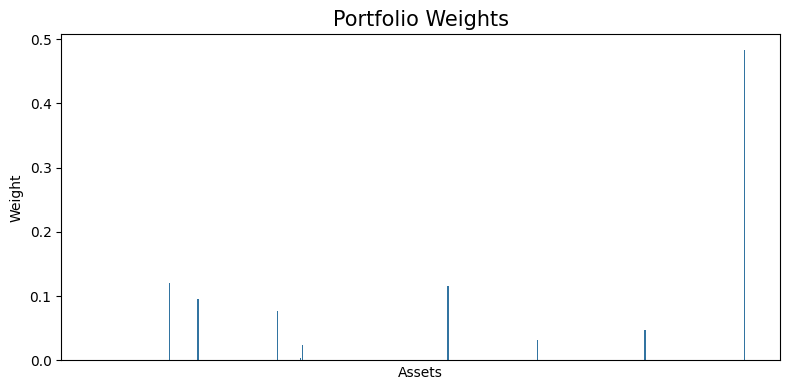

\begin{tabular}{lrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrr}
\toprule
 & A & AAPL & ABT & ACGL & ACN & ADBE & ADI & ADM & ADP & ADSK & AEE & AEP & AES & AFL & AIG & AIZ & AJG & AKAM & ALB & ALGN & ALL & AMAT & AMD & AME & AMGN & AMP & AMT & AMZN & ANSS & AON & AOS & APA & APD & APH & ARE & ATO & AVB & AVGO & AVY & AWK & AXON & AXP & AZO & BA & BAC & BALL & BAX & BBY & BDX & BEN & BG & BIIB & BK & BKNG & BKR & BLDR & BLK & BMY & BR & BRO & BSX & BWA & BX & BXP & C & CAG & CAH & CAT & CB & CBOE & CBRE & CCI & CCL & CDNS & CE & CF & CHD & CHRW & CHTR & CI & CINF & CL & CLX & CMCSA & CME & CMG & CMI & CMS

In [52]:
skfolio_portfolio.plot_weights(
    plot_ucits_limits=False,
    skip_zero_weights=False,
    zero_threshold=1e-3,
    save_as="../results/Case_02/MinCVaR_skfolio_optimizer_portfolio_weights.png",
)

Number of assets in portfolio: 9


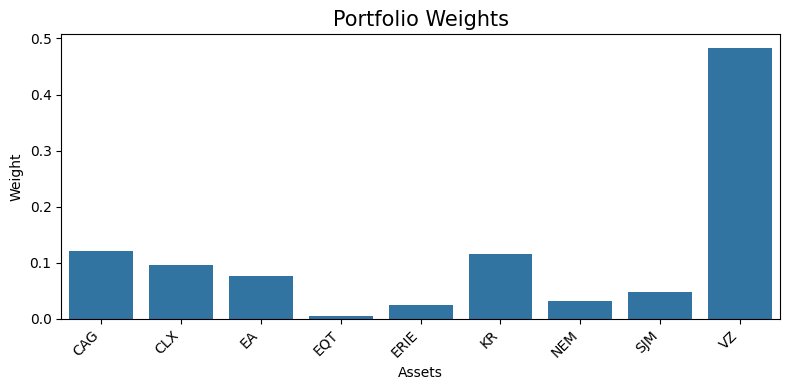

\begin{tabular}{lrrrrrrrrr}
\toprule
 & CAG & CLX & EA & EQT & ERIE & KR & NEM & SJM & VZ \\
\midrule
Weight & 0.120858 & 0.095492 & 0.076341 & 0.004152 & 0.024177 & 0.116439 & 0.032169 & 0.047150 & 0.483222 \\
\bottomrule
\end{tabular}



In [53]:
skfolio_portfolio.plot_weights(
    plot_ucits_limits=False,
    skip_zero_weights=True,
    zero_threshold=1e-3,
    save_as="../results/Case_02/MinCVaR_skfolio_optimizer_portfolio_weights_no_zeros.png",
)

## Portfolio optimization using gradient descent

In [54]:
def custom_loss_function():
    def loss_function(
        assets_rets,  # Assets returns
        w,  # Portfolio weights
        idx=None,  # Index returns
    ):
        # Portfolio returns.
        p_rets = tf.matmul(assets_rets, w)

        ###############
        # CVaR
        ###############
        # Calculate CVaR at 95%.
        # This function gives the result in positive.
        cvar = rm.RiskMeasures.CVaR_tf(x=p_rets, alpha=0.05)

        # Update the loss.
        loss = cvar

        return {
            "loss": loss,  # Only for training, without converting to numpy.
            "weights": w.numpy(),
            "metrics": {
                "loss": loss.numpy(),
                "cvar": cvar.numpy(),
            },
        }

    return loss_function

In [55]:
def custom_get_best_weights():
    def get_best_weights(history: list) -> np.ndarray:
        weights = pd.DataFrame([h["weights"].squeeze() for h in history])
        metrics = pd.DataFrame([h["metrics"] for h in history])
        idx_min_loss = metrics["loss"].idxmin()
        selected_weights = weights.loc[idx_min_loss].to_numpy()
        return selected_weights.squeeze()

    return get_best_weights

In [56]:
def custom_weights_function():
    return sparsemax

In [57]:
# MPOModel parameters.
num_assets = X_train.shape[1]
loss_function = custom_loss_function()
weights_function = custom_weights_function()
get_best_weights_function = custom_get_best_weights()
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

# Create and fit the MPOModel.
mpo = MPOModel(
    num_assets=num_assets,
    loss_function=loss_function,
    weights_function=weights_function,
    get_best_weights_function=get_best_weights_function,
    optimizer=optimizer,
    random_weight_init=False,
)
history = mpo.fit(x=X_train, idx=y_train, epochs=2000)

100%|██████████| 2000/2000 [01:13<00:00, 27.04it/s]


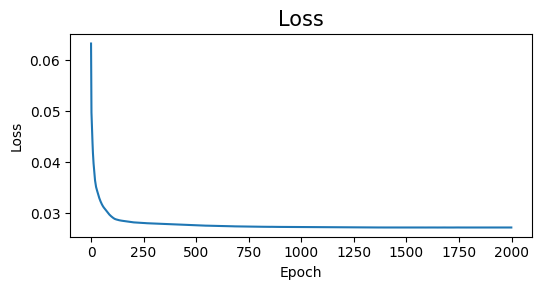

In [58]:
mpo.plot_all_training_metrics(
    save_as="../results/Case_02/MinCVaR_gd_optimizer_training_metrics.png",
    titles={
        "loss": "Loss",
        "cvar": "CVaR",
    },
)

In [59]:
gd_portfolio_name = "Case 2 - GD"
gd_portfolio = Portfolio(
    name=gd_portfolio_name,
    asset_weights=mpo.get_best_weights(),
    asset_names=X_train.columns,
)

Number of assets in portfolio: 10


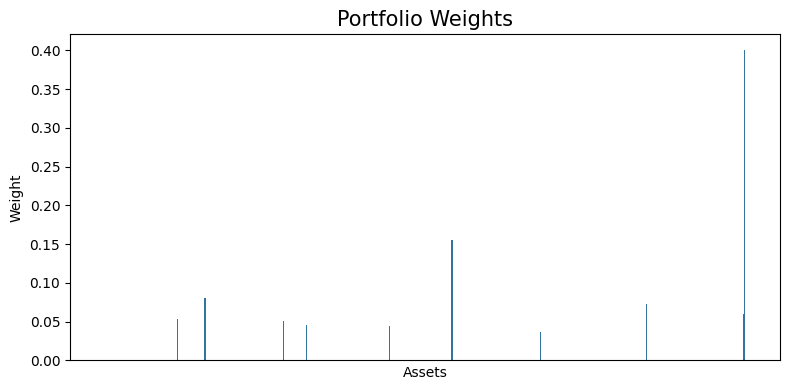

\begin{tabular}{lrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrr}
\toprule
 & A & AAPL & ABT & ACGL & ACN & ADBE & ADI & ADM & ADP & ADSK & AEE & AEP & AES & AFL & AIG & AIZ & AJG & AKAM & ALB & ALGN & ALL & AMAT & AMD & AME & AMGN & AMP & AMT & AMZN & ANSS & AON & AOS & APA & APD & APH & ARE & ATO & AVB & AVGO & AVY & AWK & AXON & AXP & AZO & BA & BAC & BALL & BAX & BBY & BDX & BEN & BG & BIIB & BK & BKNG & BKR & BLDR & BLK & BMY & BR & BRO & BSX & BWA & BX & BXP & C & CAG & CAH & CAT & CB & CBOE & CBRE & CCI & CCL & CDNS & CE & CF & CHD & CHRW & CHTR & CI & CINF & CL & CLX & CMCSA & CME & CMG & CMI & CMS

In [60]:
gd_portfolio.plot_weights(
    plot_ucits_limits=False,
    skip_zero_weights=False,
    save_as="../results/Case_02/MinCVaR_gd_optimizer_portfolio_weights.png",
)

Number of assets in portfolio: 10


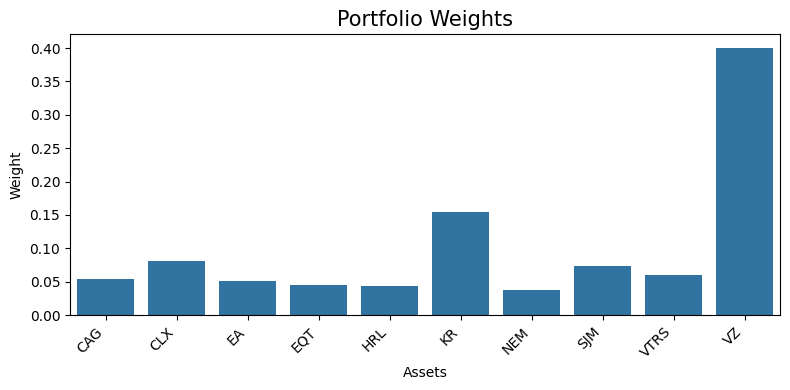

\begin{tabular}{lrrrrrrrrrr}
\toprule
 & CAG & CLX & EA & EQT & HRL & KR & NEM & SJM & VTRS & VZ \\
\midrule
Weight & 0.053394 & 0.081054 & 0.050614 & 0.045719 & 0.044217 & 0.154739 & 0.037236 & 0.073153 & 0.059327 & 0.400548 \\
\bottomrule
\end{tabular}



In [61]:
gd_portfolio.plot_weights(
    plot_ucits_limits=False,
    skip_zero_weights=True,
    save_as="../results/Case_02/MinCVaR_gd_optimizer_portfolio_weights_no_zeros.png",
)

## Comparison

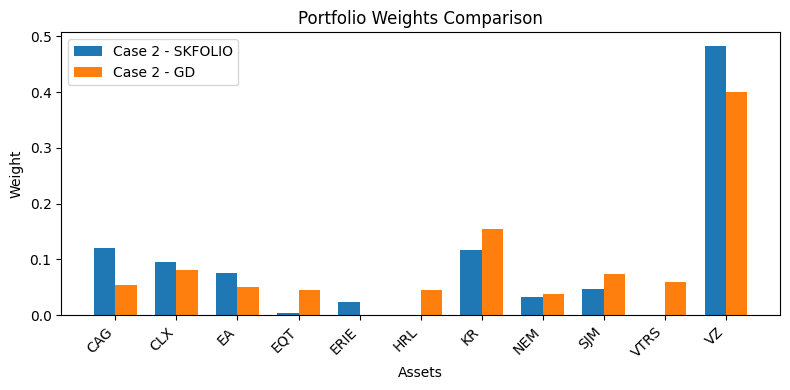

                       CAG       CLX        EA       EQT      ERIE       HRL  \
Case 2 - SKFOLIO  0.120858  0.095492  0.076341  0.004152  0.024177  0.000000   
Case 2 - GD       0.053394  0.081054  0.050614  0.045719  0.000000  0.044217   

                        KR       NEM       SJM      VTRS        VZ  
Case 2 - SKFOLIO  0.116439  0.032169  0.047150  0.000000  0.483222  
Case 2 - GD       0.154739  0.037236  0.073153  0.059327  0.400548  


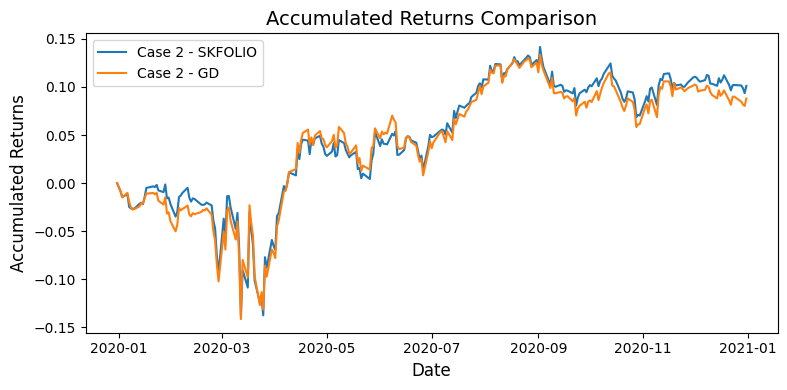

                       Std    Sharpe  TrackingError       VaR      CVaR  \
Case 2 - SKFOLIO  0.013626  0.006795       0.014815  0.018191  0.027215   
Case 2 - GD       0.013605  0.003704       0.014573  0.018153  0.027246   

                  WeightsOver10pct  WeightsOver5pct  
Case 2 - SKFOLIO          0.420519         0.892351  
Case 2 - GD               0.355287         0.872829  


In [62]:
# Allows us to store and compare different portfolios.
portfolios = Portfolio_Collection(portfolio_names=[], portfolio_weights=[], asset_names=X_train.columns)

# SKFOLIO portfolio.
portfolios.replace_or_add_portfolio(
    name=skfolio_portfolio.name,
    new_portfolio=skfolio_portfolio,
)

portfolios.replace_or_add_portfolio(name=gd_portfolio.name, new_portfolio=gd_portfolio)

# GD Portfolio.
gd_portfolio_name = f"Case 1 - GD"
portfolios.replace_or_add_portfolio(name=gd_portfolio.name, new_portfolio=gd_portfolio)

# Plotting the comparison of the two portfolios.
portfolios.plot_weight_comparison(
    portfolio_names=[
        skfolio_portfolio.name,
        gd_portfolio.name,
    ],
    plot_ucits_limits=False,
    skip_zero_weights=True,
    zero_threshold=1e-3,
    save_as="../results/Case_02/MinCVaR_portfolio_weights_comparison.png",
)

portfolios.plot_cumulative_returns(
    asset_returns=X_train,
    idx_returns=y_train,
    portfolio_names=[
        skfolio_portfolio.name,
        gd_portfolio.name,
    ],
    plot_idx=False,
    comparable_returns=[],
    rf=risk_free_return,
    zero_start=True,
    save_as="../results/Case_02/MinCVaR_portfolio_cumulative_returns_comparison.png",
)